## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import Dataset
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix

/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Load data

In [2]:
data = pd.read_csv("data/cleaned_static_features.csv",index_col=0)
with open("data/groups.pkl", 'rb') as file:
    groups = pickle.load(file)

In [3]:
disorders = ["Voice Disorders", "Neurological and Neurodegenerative Disorders", "Mood and Psychiatric Disorders","Respiratory Disorders"]
y_voice = data["Voice Disorders"].copy().to_numpy()
X = data.copy().drop(columns=["participant_id", "session_id","task_name","participant_id_int"]+disorders).to_numpy()

## Preprocessing

### Average over sessions within subject

In [4]:
n_subj = groups[-1]+1
X_ave = np.zeros((n_subj, X.shape[1]))
y_voice_ave = np.zeros(n_subj)
for g in np.arange(n_subj):
    curr_X = X[np.where(groups==g)].mean(axis=0)
    X_ave[g] = curr_X
    y_voice_ave[g] = y_voice[np.where(groups==g)].mean()
print(X_ave.shape)

(442, 96)


## Train Decision Tree with hyperparameter tuning

In [5]:
# Run GridSearchCV only for Voice disorder and visualize all combinations' train vs validation performance
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def grid_search(param_grid:dict, y_curr, label:str, n_splits:int=10):
    # Split off a held-out test set (never used for CV)
    X_tr, X_te, y_tr, y_te = train_test_split(X_ave, y_curr, test_size=0.15, random_state=42, stratify=y_curr)

    base_dt = DecisionTreeClassifier(random_state=42)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

    gscv = GridSearchCV(base_dt, param_grid, scoring='f1_weighted', cv=skf, n_jobs=-1, refit=True, return_train_score=True)
    gscv.fit(X_tr, y_tr)

    # Convert cv_results_ into a DataFrame for easier analysis
    cv_res = pd.DataFrame(gscv.cv_results_)
    # keep only relevant cols
    cols = ['params','mean_train_score','std_train_score','mean_test_score','std_test_score','rank_test_score']
    summary_grid = cv_res[cols].sort_values('rank_test_score').reset_index(drop=True)

    print('Top 5 hyperparameter combinations (by validation rank):')
    for i, row in summary_grid.head(5).iterrows():
        print(f"Rank {int(row['rank_test_score'])}: val={row['mean_test_score']:.4f}, train={row['mean_train_score']:.4f}, params={row['params']}")

    # Scatter plot: train vs validation for every combo
    fig, ax = plt.subplots(figsize=(8,6))
    x = summary_grid['mean_train_score']
    y = summary_grid['mean_test_score']
    sc = ax.scatter(x, y, c=summary_grid['rank_test_score'], cmap='viridis', s=60, edgecolor='k')
    ax.plot([0,1],[0,1],'--',color='gray',linewidth=1)  # reference line where train==val
    ax.set_xlabel('Mean Train F1 (CV)')
    ax.set_ylabel('Mean Validation F1 (CV)')
    ax.set_title('Train vs Validation F1 for all hyperparameter combinations (Voice)')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Rank (lower is better)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot the overfitting gap (train - val) sorted by rank
    summary_grid['train_minus_val'] = summary_grid['mean_train_score'] - summary_grid['mean_test_score']
    fig, ax = plt.subplots(figsize=(10,4))
    ax.bar(range(len(summary_grid)), summary_grid['train_minus_val'], color='C1')
    ax.set_xlabel('Hyperparameter combination (sorted by validation rank)')
    ax.set_ylabel('Train F1 - Validation F1')
    ax.set_title('Overfitting gap per hyperparameter combination (Voice)')
    plt.tight_layout()
    plt.show()

    # Evaluate best estimator on held-out test set and show report
    best = gscv.best_estimator_
    y_test_pred = best.predict(X_te)
    test_f1 = f1_score(y_te, y_test_pred, average='weighted')
    print('Classification report (test):')
    print(classification_report(y_te, y_test_pred))
    print('Confusion matrix (test):')
    print(confusion_matrix(y_te, y_test_pred))

    # Save results to a dict for later use
    grid_search_results = {'cv_results_df': summary_grid, 'best_params': gscv.best_params_, 'best_score_cv': gscv.best_score_, 'test_f1': test_f1, 'best_estimator': best}
    return grid_search_results


Top 5 hyperparameter combinations (by validation rank):
Rank 1: val=0.6863, train=0.8790, params={'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 10}
Rank 2: val=0.6842, train=0.8915, params={'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 2, 'min_samples_split': 5}
Rank 3: val=0.6806, train=0.8905, params={'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Rank 4: val=0.6738, train=0.8188, params={'class_weight': None, 'criterion': 'entropy', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2}
Rank 5: val=0.6734, train=0.8446, params={'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 10}


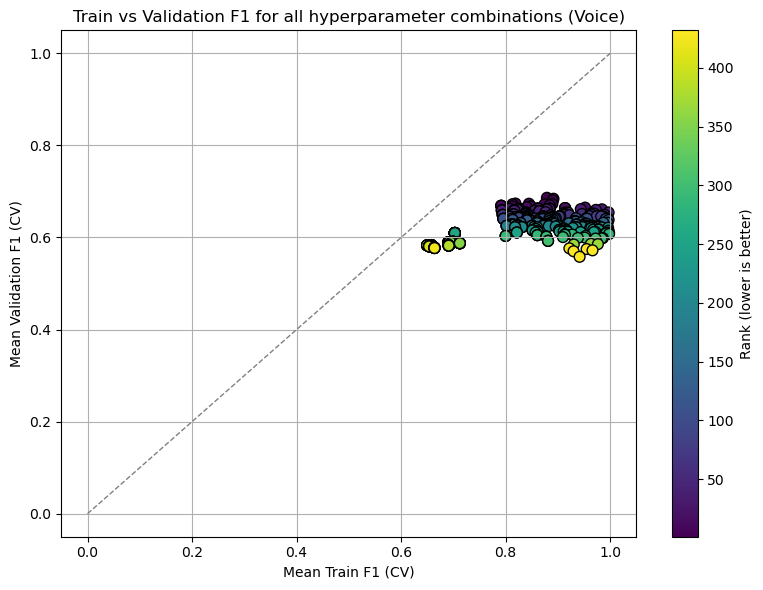

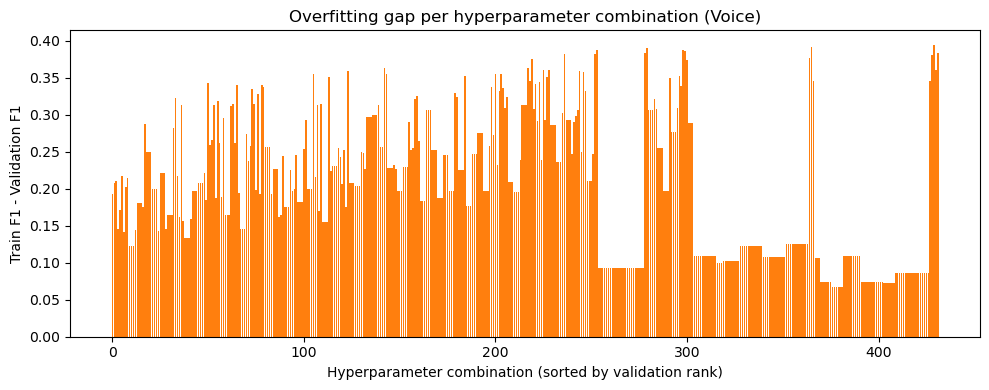

Classification report (test):
              precision    recall  f1-score   support

         0.0       0.55      0.72      0.62        32
         1.0       0.64      0.46      0.53        35

    accuracy                           0.58        67
   macro avg       0.59      0.59      0.58        67
weighted avg       0.60      0.58      0.58        67

Confusion matrix (test):
[[23  9]
 [19 16]]


In [6]:
# Recommended parameter grid for DecisionTreeClassifier (covers regularization and split options)
param_grid = {
    "max_depth": [2, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", 0.5, None],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

grid_search_voice = grid_search(param_grid, y_voice_ave, "Voice")

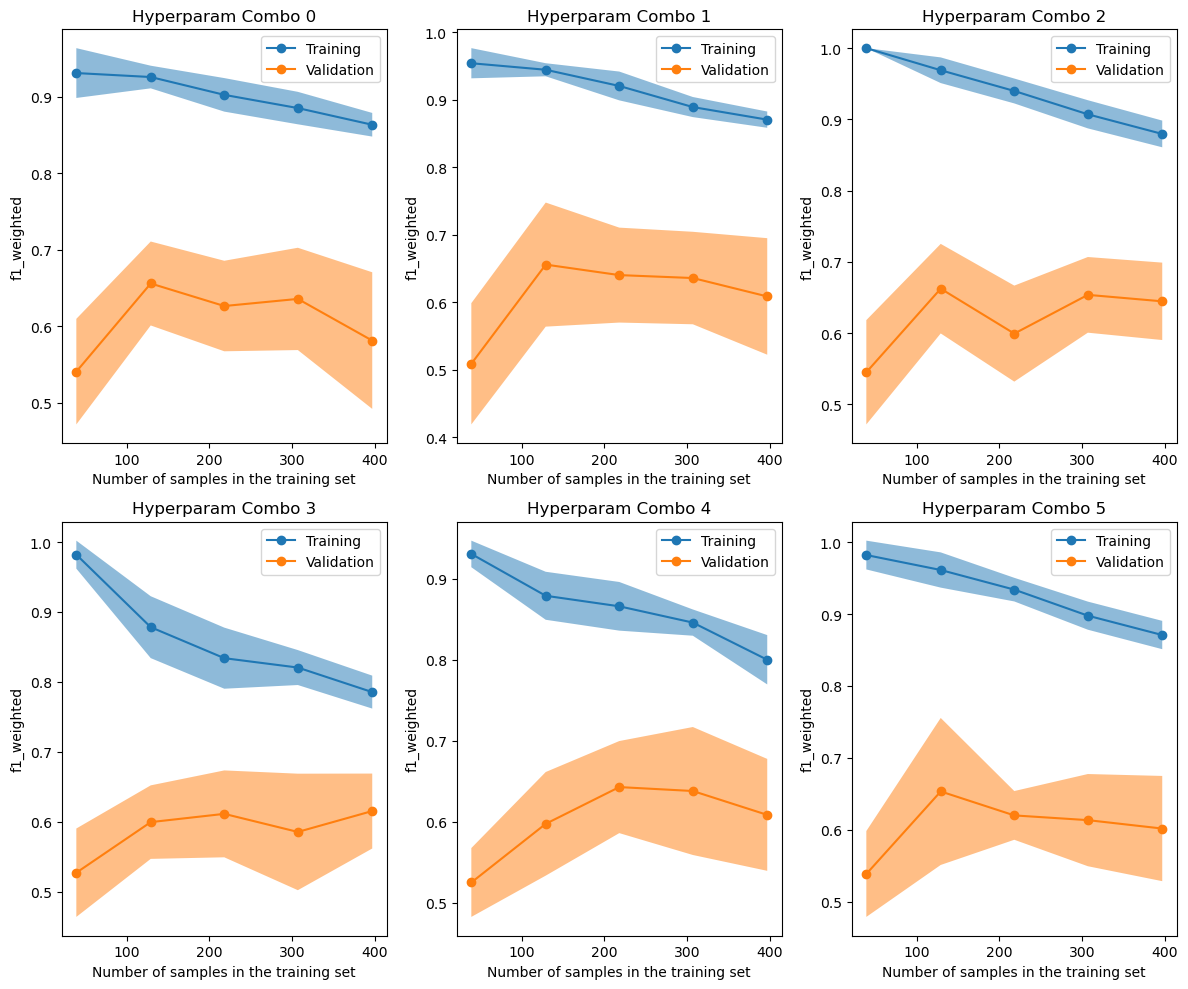

In [8]:
top_params = grid_search_voice["cv_results_df"].sort_values("rank_test_score",ascending=True)[:6]['params'].tolist()

from sklearn.model_selection import LearningCurveDisplay, ShuffleSplit

fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 10))

common_params = {
    "X": X_ave,
    "y": y_voice_ave,
    "train_sizes": np.linspace(0.1, 1.0, 5),
    "cv": StratifiedKFold(n_splits=10, shuffle=True, random_state=42),
    "score_type": "both",
    "n_jobs": 4,
    "line_kw": {"marker": "o"},
    "std_display_style": "fill_between",
    "score_name": "f1_weighted",
}

for i,(ax,params) in enumerate(zip(axes.flatten(), top_params)):
    estimator = DecisionTreeClassifier(**params)
    LearningCurveDisplay.from_estimator(estimator, **common_params, ax=ax)
    
    handles, label = ax.get_legend_handles_labels()
    ax.legend(handles[:2], ["Training", "Validation"])
    ax.set_title(f"Hyperparam Combo {i}") 

plt.tight_layout()
plt.show()

In [9]:
grid_search_voice["cv_results_df"].sort_values(by="train_minus_val",ascending=True)[:10]

,params,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score,train_minus_val
376,"{'class_weight': None, 'criterion': 'entropy',...",0.649700,0.026092,0.583052,0.097698,377,0.066648
381,"{'class_weight': None, 'criterion': 'entropy',...",0.649700,0.026092,0.583052,0.097698,377,0.066648
380,"{'class_weight': None, 'criterion': 'entropy',...",0.649700,0.026092,0.583052,0.097698,377,0.066648
379,"{'class_weight': 'balanced', 'criterion': 'ent...",0.649700,0.026092,0.583052,0.097698,377,0.066648
378,"{'class_weight': 'balanced', 'criterion': 'ent...",0.649700,0.026092,0.583052,0.097698,377,0.066648
377,"{'class_weight': 'balanced', 'criterion': 'ent...",0.649700,0.026092,0.583052,0.097698,377,0.066648
403,"{'class_weight': 'balanced', 'criterion': 'ent...",0.653438,0.023672,0.580709,0.097420,404,0.072729
404,"{'class_weight': 'balanced', 'criterion': 'ent...",0.653438,0.023672,0.580709,0.097420,404,0.072729
406,"{'class_weight': None, 'criterion': 'entropy',...",0.653438,0.023672,0.580709,0.097420,404,0.072729
407,"{'class_weight': None, 'criterion': 'entropy',...",0.653438,0.023672,0.580709,0.097420,404,0.072729


In [10]:
grid_search_voice["cv_results_df"].sort_values(by="rank_test_score",ascending=True)[:10]

,params,mean_train_score,std_train_score,mean_test_score,std_test_score,rank_test_score,train_minus_val
0,"{'class_weight': 'balanced', 'criterion': 'gin...",0.879016,0.014533,0.686295,0.070948,1,0.192722
1,"{'class_weight': None, 'criterion': 'gini', 'm...",0.891513,0.011001,0.684175,0.038803,2,0.207338
2,"{'class_weight': None, 'criterion': 'gini', 'm...",0.890543,0.019763,0.680637,0.065043,3,0.209906
3,"{'class_weight': None, 'criterion': 'entropy',...",0.818837,0.019106,0.673785,0.090205,4,0.145051
4,"{'class_weight': 'balanced', 'criterion': 'gin...",0.844605,0.022561,0.673399,0.054323,5,0.171206
5,"{'class_weight': None, 'criterion': 'gini', 'm...",0.889353,0.017144,0.672849,0.060389,6,0.216505
6,"{'class_weight': None, 'criterion': 'entropy',...",0.813161,0.017571,0.672340,0.097888,7,0.140820
7,"{'class_weight': 'balanced', 'criterion': 'gin...",0.874474,0.014988,0.671978,0.091262,8,0.202496
8,"{'class_weight': None, 'criterion': 'gini', 'm...",0.884310,0.016552,0.670039,0.062054,9,0.214271
9,"{'class_weight': 'balanced', 'criterion': 'gin...",0.791485,0.019054,0.668961,0.072454,10,0.122524


## Group K Fold
- Leave one group out is making the model overfit because the test folds are too small. Let's try leaving out more groups than one.

In [30]:
def train_test_split_groups(y, groups, total_n_groups:int, split_size:float=0.15):
    n_test_groups = int(total_n_groups*0.15)
    group_ones = groups[np.where(y==1)[0]]
    group_zeros = groups[np.where(y==0)[0]]
    test_groups_one = np.random.choice(group_ones, int(n_test_groups/2), replace=False)
    test_groups_zero = np.random.choice(group_zeros, int(n_test_groups/2), replace=False)
    test_groups = np.concatenate((test_groups_one, test_groups_zero))
    train_groups = np.array([g for g in groups if g not in test_groups])
    train_inds = np.array([i for i in range(len(y)) if groups[i] in train_groups])
    test_inds = np.array([i for i in range(len(y)) if groups[i] in test_groups])
    return train_inds, test_inds
train_idx, test_idx = train_test_split_groups(y_voice, groups, total_n_groups=440)
X_train, y_train = X[train_idx], y_voice[train_idx]
X_test, y_test = X[test_idx], y_voice[test_idx]

In [31]:
n_train_groups = len(np.unique(groups[train_idx]))
ideal_n_test_groups = int(n_train_groups*0.15)
ave_n_sessions_per_group = int(len(groups[train_idx])/n_train_groups)
ideal_n_test_inds = ideal_n_test_groups * ave_n_sessions_per_group
n_splits = int(np.ceil(len(groups[train_idx])/ideal_n_test_inds))

In [32]:
# Preprocess, train, and evaluate DecisionTree with LOGO and record per-fold train/val metrics
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
import numpy as np
import pandas as pd

gkf = GroupKFold(n_splits=n_splits,shuffle=False)
fold_results = []

for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X_train, y_train, groups=groups[train_idx])):
    # Train/validation split at group level
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[te_idx], y_train[te_idx]

    clf = DecisionTreeClassifier(random_state=42)

    # Fit on training groups
    clf.fit(X_tr, y_tr)

    # Evaluate on training groups (report group-level aggregated performance)
    y_tr_pred = clf.predict(X_tr)
    train_f1 = f1_score(y_tr, y_tr_pred, average='weighted')

    # Evaluate on held-out group (validation)
    y_val_pred = clf.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    fold_results.append({
        'fold': fold_idx,
        'train_idx_count': len(tr_idx),
        'val_idx_count': len(te_idx),
        'train_f1': train_f1,
        'val_f1': val_f1,
        'val_groups': np.unique(groups[te_idx]).tolist()
    })

# Convert to DataFrame for easier plotting/analysis
decision_tree_gkf_fold_results = pd.DataFrame(fold_results)
print('Per-fold GKF results (first 10 rows):')
print(decision_tree_gkf_fold_results.head(10))


Per-fold GKF results (first 10 rows):
   fold  train_idx_count  val_idx_count  train_f1    val_f1  \
0     0            13966           2320       1.0  0.584633   
1     1            13966           2320       1.0  0.585570   
2     2            13966           2320       1.0  0.589285   
3     3            13949           2337       1.0  0.571232   
4     4            13950           2336       1.0  0.589099   
5     5            13952           2334       1.0  0.593961   
6     6            13967           2319       1.0  0.610631   

                                          val_groups  
0  [1, 2, 3, 4, 15, 16, 17, 19, 20, 25, 26, 28, 2...  
1  [0, 1, 26, 27, 28, 40, 41, 44, 45, 47, 48, 49,...  
2  [1, 13, 14, 15, 24, 25, 35, 36, 42, 43, 44, 57...  
3  [4, 5, 6, 7, 12, 13, 18, 19, 22, 23, 29, 30, 3...  
4  [1, 7, 8, 9, 10, 11, 15, 16, 23, 24, 52, 53, 5...  
5  [8, 9, 11, 12, 17, 18, 20, 21, 37, 38, 46, 47,...  
6  [2, 3, 21, 22, 33, 34, 44, 45, 51, 52, 63, 64,...  


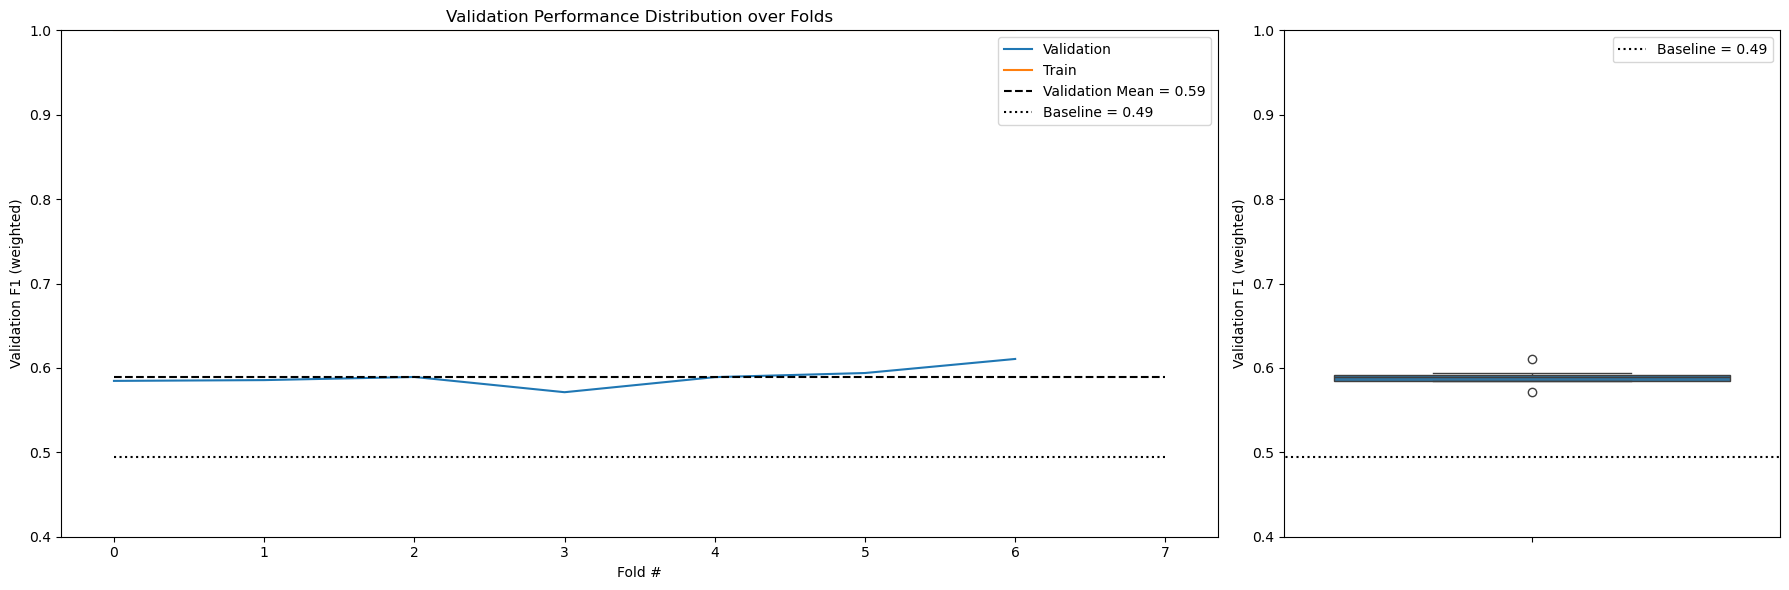

In [40]:
import seaborn as sns

val_mean = decision_tree_gkf_fold_results["val_f1"].mean()
baseline_mean = y_voice.mean()

fig,axes = plt.subplots(1,2,figsize=(18,6),width_ratios=[0.7,0.3])

sns.lineplot(data=decision_tree_gkf_fold_results,x="fold",y="val_f1",ax=axes[0],label="Validation")
sns.lineplot(data=decision_tree_gkf_fold_results,x="fold",y="train_f1",ax=axes[0],label="Train")
axes[0].plot([0,n_splits],[val_mean, val_mean], ls="--",c="k",label=f"Validation Mean = {np.round(val_mean, 2)}")
axes[0].plot([0,n_splits],[baseline_mean, baseline_mean], ls="dotted",c="k",label=f"Baseline = {np.round(baseline_mean, 2)}")
axes[0].set_ylabel("Validation F1 (weighted)")
axes[0].set_ylim([0.4, 1.0])
axes[0].set_xlabel("Fold #")
axes[0].legend()
axes[0].set_title("Validation Performance Distribution over Folds")

sns.boxplot(data=decision_tree_gkf_fold_results, y="val_f1",ax=axes[1])
axes[1].plot([-1,2], [baseline_mean, baseline_mean], ls="dotted", c="k", label=f"Baseline = {np.round(baseline_mean,2)}")
axes[1].set_ylabel("Validation F1 (weighted)")
axes[1].set_xlim([-0.5, 0.5])
axes[1].set_ylim([0.4, 1.0])
axes[1].legend()
plt.tight_layout()
plt.show()

## Hyperparameter tuning with GroupKFold

In [38]:
# Run GridSearchCV only for Voice disorder and visualize all combinations' train vs validation performance
from sklearn.model_selection import GridSearchCV, GroupKFold, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def grid_search(param_grid:dict, X, y, groups, label:str, n_splits:int=7):
    base_dt = DecisionTreeClassifier(random_state=42)

    gkf = GroupKFold(n_splits=n_splits)

    gscv = GridSearchCV(base_dt, param_grid, scoring='f1_weighted', cv=gkf, n_jobs=-1, refit=True, return_train_score=True)
    gscv.fit(X, y, groups=groups)

    # Convert cv_results_ into a DataFrame for easier analysis
    cv_res = pd.DataFrame(gscv.cv_results_)
    # keep only relevant cols
    cols = ['params','mean_train_score','std_train_score','mean_test_score','std_test_score','rank_test_score']
    summary_grid = cv_res[cols].sort_values('rank_test_score').reset_index(drop=True)

    print('Top 5 hyperparameter combinations (by validation rank):')
    for i, row in summary_grid.head(5).iterrows():
        print(f"Rank {int(row['rank_test_score'])}: val={row['mean_test_score']:.4f}, train={row['mean_train_score']:.4f}, params={row['params']}")

    # Scatter plot: train vs validation for every combo
    fig, ax = plt.subplots(figsize=(8,6))
    x = summary_grid['mean_train_score']
    y = summary_grid['mean_test_score']
    sc = ax.scatter(x, y, c=summary_grid['rank_test_score'], cmap='viridis', s=60, edgecolor='k')
    ax.plot([0,1],[0,1],'--',color='gray',linewidth=1)  # reference line where train==val
    ax.set_xlabel('Mean Train F1 (CV)')
    ax.set_ylabel('Mean Validation F1 (CV)')
    ax.set_title('Train vs Validation F1 for all hyperparameter combinations (Voice)')
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Rank (lower is better)')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot the overfitting gap (train - val) sorted by rank
    summary_grid['train_minus_val'] = summary_grid['mean_train_score'] - summary_grid['mean_test_score']
    fig, ax = plt.subplots(figsize=(10,4))
    ax.bar(range(len(summary_grid)), summary_grid['train_minus_val'], color='C1')
    ax.set_xlabel('Hyperparameter combination (sorted by validation rank)')
    ax.set_ylabel('Train F1 - Validation F1')
    ax.set_title('Overfitting gap per hyperparameter combination (Voice)')
    plt.tight_layout()
    plt.show()

    # Evaluate best estimator on held-out test set and show report
    best = gscv.best_estimator_

    # Save results to a dict for later use
    grid_search_results = {'cv_results_df': summary_grid, 'best_params': gscv.best_params_, 'best_score_cv': gscv.best_score_, 'best_estimator': best}
    return grid_search_results


Top 5 hyperparameter combinations (by validation rank):
Rank 1: val=0.6329, train=0.6647, params={'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 5}
Rank 1: val=0.6329, train=0.6647, params={'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2}
Rank 1: val=0.6329, train=0.6647, params={'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 10}
Rank 4: val=0.6329, train=0.6648, params={'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Rank 4: val=0.6329, train=0.6648, params={'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2}


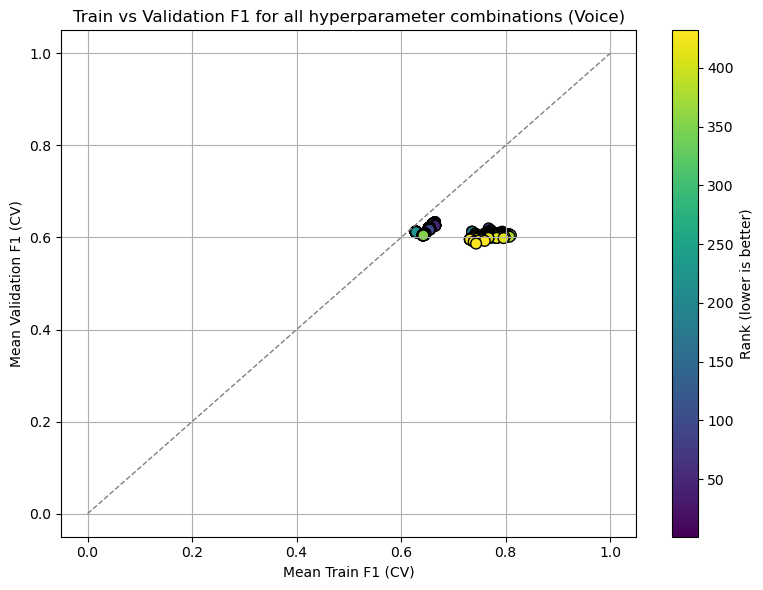

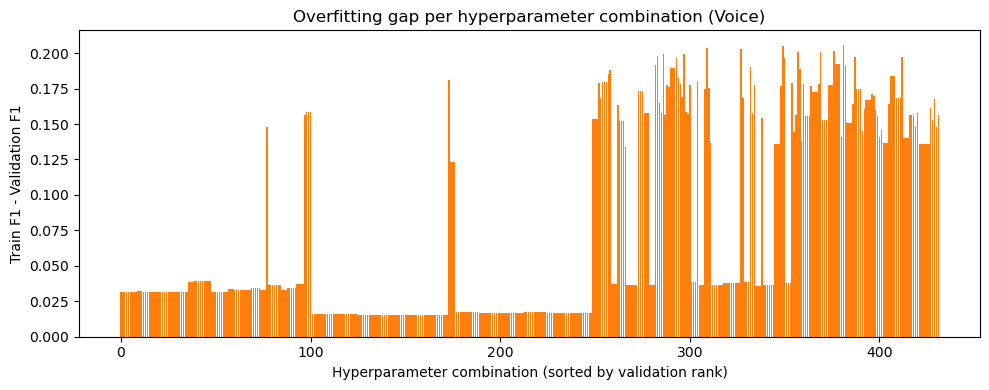

In [39]:
# Recommended parameter grid for DecisionTreeClassifier (covers regularization and split options)
param_grid = {
    "max_depth": [2, 5, 10],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5, 10],
    "max_features": ["sqrt", 0.5, None],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

grid_search_voice = grid_search(param_grid, X_train, y_train, groups[train_idx], "Voice", n_splits)

In [41]:
best_params = {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 5}

## Train and test for best performing decision tree (that isn't overfitting)

In [42]:
gkf = GroupKFold(n_splits=n_splits,shuffle=False)
fold_results = []

clf = DecisionTreeClassifier(random_state=42, **best_params)

for fold_idx, (tr_idx, val_idx) in enumerate(gkf.split(X_train, y_train, groups=groups[train_idx])):
    # Train/test split at group level
    X_tr, y_tr = X_train[tr_idx], y_train[tr_idx]
    X_val, y_val = X_train[val_idx], y_train[val_idx]

    # Fit on training groups
    clf.fit(X_tr, y_tr)

    # Evaluate on training groups (report group-level aggregated performance)
    y_tr_pred = clf.predict(X_tr)
    train_f1 = f1_score(y_tr, y_tr_pred, average='weighted')

    # Evaluate on held-out group (validation)
    y_val_pred = clf.predict(X_val)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    fold_results.append({
        'fold': fold_idx,
        'train_idx_count': len(tr_idx),
        'val_idx_count': len(val_idx),
        'train_f1': train_f1,
        'val_f1': val_f1,
        'val_groups': np.unique(groups[val_idx]).tolist()
    })

# Convert to DataFrame for easier plotting/analysis
decision_tree_gkf_fold_results = pd.DataFrame(fold_results)
print('Per-fold GKF results (first 10 rows):')
decision_tree_gkf_fold_results.head(10)

Per-fold GKF results (first 10 rows):


,fold,train_idx_count,val_idx_count,train_f1,val_f1,val_groups
0,0,13966,2320,0.662665,0.645391,"[1, 2, 3, 4, 15, 16, 17, 19, 20, 25, 26, 28, 2..."
1,1,13966,2320,0.668709,0.651482,"[0, 1, 26, 27, 28, 40, 41, 44, 45, 47, 48, 49,..."
2,2,13966,2320,0.651537,0.632973,"[1, 13, 14, 15, 24, 25, 35, 36, 42, 43, 44, 57..."
3,3,13949,2337,0.672407,0.611561,"[4, 5, 6, 7, 12, 13, 18, 19, 22, 23, 29, 30, 3..."
4,4,13950,2336,0.672542,0.621130,"[1, 7, 8, 9, 10, 11, 15, 16, 23, 24, 52, 53, 5..."
5,5,13952,2334,0.661488,0.613925,"[8, 9, 11, 12, 17, 18, 20, 21, 37, 38, 46, 47,..."
6,6,13967,2319,0.663376,0.653957,"[2, 3, 21, 22, 33, 34, 44, 45, 51, 52, 63, 64,..."


In [43]:
# final eval
y_test_preds = clf.predict(X_test)
test_f1 = f1_score(y_test, y_test_preds, average="weighted")
print(f"Test F1 (weighted): {np.round(test_f1,2)}")

Test F1 (weighted): 0.7


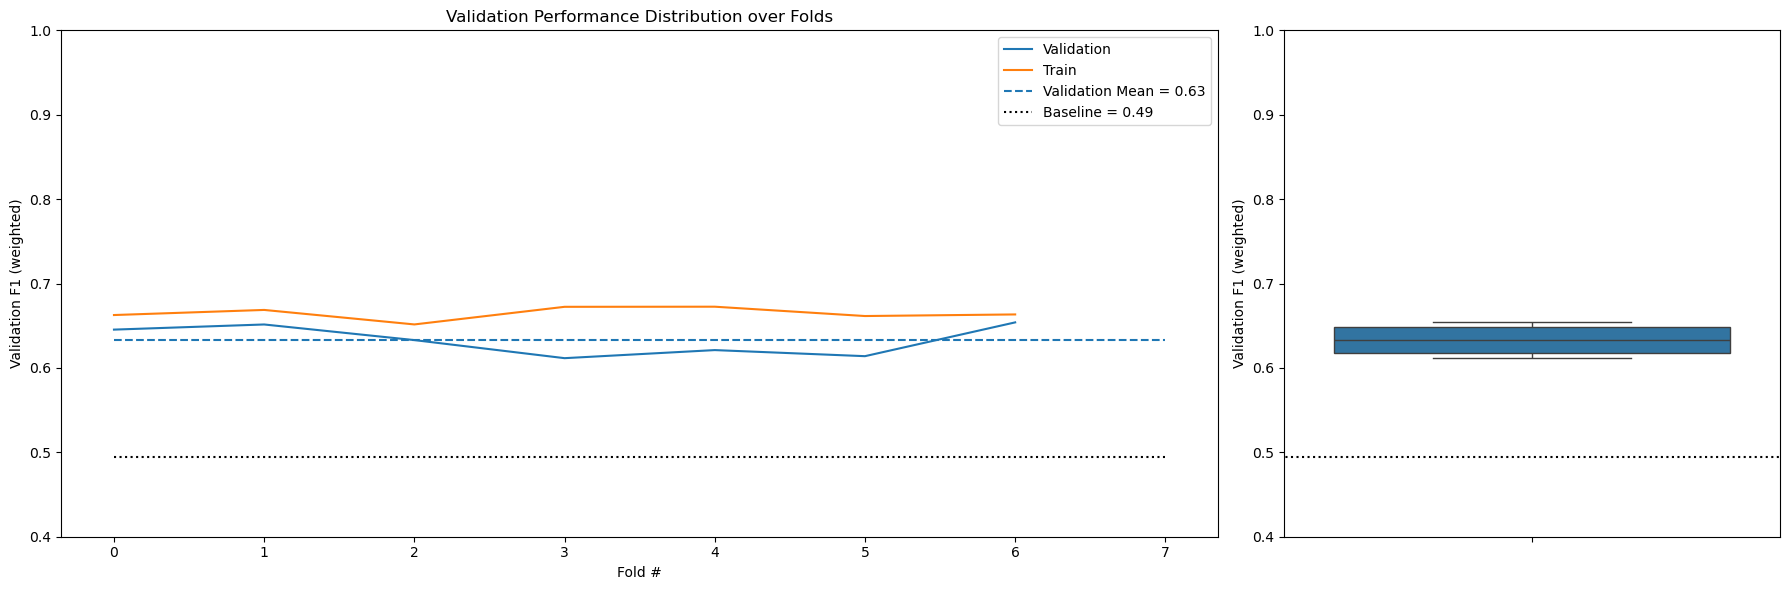

In [45]:
import seaborn as sns

val_mean = decision_tree_gkf_fold_results["val_f1"].mean()
baseline_mean = y_voice.mean()

fig,axes = plt.subplots(1,2,figsize=(18,6),width_ratios=[0.7,0.3])

sns.lineplot(data=decision_tree_gkf_fold_results,x="fold",y="val_f1",ax=axes[0],label="Validation")
sns.lineplot(data=decision_tree_gkf_fold_results,x="fold",y="train_f1",ax=axes[0],label="Train")
axes[0].plot([0,n_splits],[val_mean, val_mean], ls="--",c="tab:blue",label=f"Validation Mean = {np.round(val_mean, 2)}")
axes[0].plot([0,n_splits],[baseline_mean, baseline_mean], ls="dotted",c="k",label=f"Baseline = {np.round(baseline_mean, 2)}")
axes[0].set_ylabel("Validation F1 (weighted)")
axes[0].set_ylim([0.4, 1.0])
axes[0].set_xlabel("Fold #")
axes[0].legend()
axes[0].set_title("Validation Performance Distribution over Folds")

sns.boxplot(data=decision_tree_gkf_fold_results, y="val_f1",ax=axes[1])
axes[1].plot([-1,2], [baseline_mean, baseline_mean], ls="dotted", c="k")
axes[1].set_ylabel("Validation F1 (weighted)")
axes[1].set_xlim([-0.5, 0.5])
axes[1].set_ylim([0.4, 1.0])
plt.tight_layout()
plt.show()

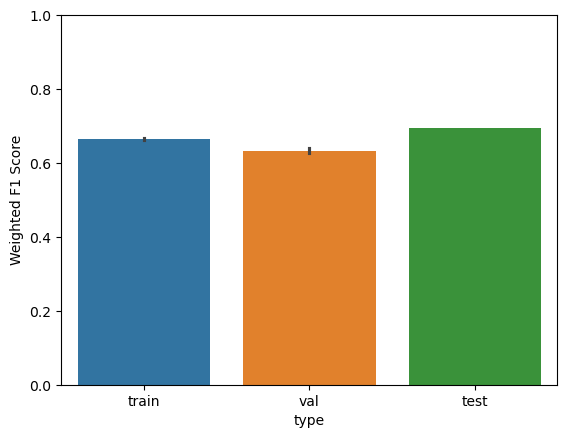

In [46]:
train_f1 = decision_tree_gkf_fold_results["train_f1"].mean()
val_f1 = decision_tree_gkf_fold_results["val_f1"].mean()

results_dict = {"f1":[], "type":[]}
for idx,row in decision_tree_gkf_fold_results.iterrows():
    results_dict["f1"].append(row.train_f1)
    results_dict["type"].append("train")
    results_dict["f1"].append(row.val_f1)
    results_dict["type"].append("val")
results_dict["f1"].append(test_f1)
results_dict["type"].append("test")

results_df = pd.DataFrame.from_dict(results_dict)

plt.figure()
sns.barplot(data=results_df, x="type", y="f1", palette="tab10", hue="type", errorbar="se")
plt.ylabel("Weighted F1 Score")
plt.ylim([0, 1.0])
plt.show()

In [53]:
train_mean = results_df[results_df["type"]=="train"]["f1"].mean()
val_mean = results_df[results_df["type"]=="val"]["f1"].mean()
test_score = results_df[results_df["type"]=="test"]["f1"].mean()
print(f"Train F1 = {np.round(train_mean,2)}")
print(f"Val F1 = {np.round(val_mean,2)}")
print(f"Test F1 = {np.round(test_score,2)}")

Train F1 = 0.66
Val F1 = 0.63
Test F1 = 0.7


In [47]:
# save model
import pickle
filepath = 'models/decision-tree-trained.pkl'
with open(filepath, 'wb') as file:
    pickle.dump(clf, file)